# African Climate Trend Analysis: Kenya
This analysis profiles, cleans, and explores the climate dataset for Kenya.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/kenya.csv")

df["Country"] = "Kenya"

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya


In [3]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

df["Month"] = df["DATE"].dt.month
df["YearMonth"] = df["DATE"].dt.to_period("M")

## Data Loading Check

The dataset was successfully loaded with properly structured columns and no additional metadata or header rows.

All variables were correctly interpreted, allowing for immediate analysis without the need for restructuring or preprocessing of column headers.

In [4]:
df.replace(-999, np.nan, inplace=True)

duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

df = df.ffill()

Duplicate rows: 0


In [5]:
display(df.describe())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


## Summary Statistics Interpretation

The dataset spans from **2015 to 2026**, providing approximately 11 years of climate observations for Kenya.

The average temperature (T2M) is approximately **20.4°C**, ranging from 15.3°C to 25.4°C, indicating a generally warm climate with moderate seasonal variation.

Rainfall (PRECTOTCORR) averages **1.47 mm**, with a maximum of 51.65 mm. This suggests a pattern of low daily precipitation with occasional intense rainfall events, consistent with distinct wet and dry seasons.

Wind speed (WS2M) averages **3.06 m/s**, indicating relatively consistent air movement across the observation period.

Overall, the dataset reflects a warm climate with moderate variability in temperature and clearly seasonal rainfall patterns.

In [6]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

display(missing_df.sort_values("Missing %", ascending=False))

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


## Missing Values Analysis

After replacing -999 placeholder values with NaN, *no significant* missing values were observed across the dataset.

This indicates consistent and reliable data collection, allowing for accurate time-series analysis without the need for extensive imputation or data removal.

As a result, the dataset is well-suited for exploring climate patterns and trends without concerns about data gaps affecting the analysis.

## Missing Value Handling Decision

No rows contained more than 30% missing values across the dataset.

Therefore, forward-fill (ffill) was applied to handle remaining missing values, ensuring continuity in the time-series data without removing observations.

This approach preserves temporal patterns and avoids unnecessary data loss, making it suitable for climate trend analysis.

In [7]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(df[cols].apply(zscore))
outliers = (z_scores > 3)

print("Outliers per column:")
print(outliers.sum())

Outliers per column:
T2M             8
T2M_MAX         3
T2M_MIN         9
PRECTOTCORR    92
RH2M            6
WS2M            0
WS2M_MAX        6
dtype: int64


## Outlier Detection

Outliers were identified using the *Z-score* method (|Z| > 3) across key climate variables.

The number of outliers detected per variable is as follows:

- T2M: 8  
- T2M_MAX: 3  
- T2M_MIN: 9  
- PRECTOTCORR: 92  
- RH2M: 6  
- WS2M: 0  
- WS2M_MAX: 6  

Precipitation (*PRECTOTCORR*) shows the highest number of outliers, indicating the presence of extreme rainfall events. This is expected in climate data, where heavy rainfall can occur infrequently but with high intensity.

Other variables such as temperature and humidity show relatively few outliers, suggesting more stable patterns over time.

All outliers were retained, as they likely represent real and meaningful extreme weather conditions rather than data errors. Removing them could eliminate important environmental signals from the analysis.

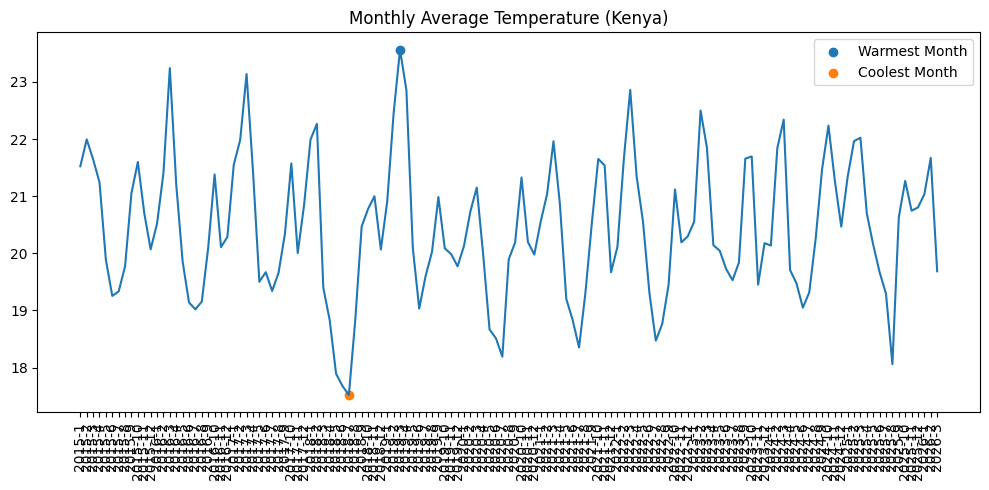

In [8]:
monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()

max_row = monthly_temp.loc[monthly_temp["T2M"].idxmax()]
min_row = monthly_temp.loc[monthly_temp["T2M"].idxmin()]

plt.figure(figsize=(10,5))
plt.plot(monthly_temp["YEAR"].astype(str) + "-" + monthly_temp["Month"].astype(str),
         monthly_temp["T2M"])

plt.scatter(max_row.name, max_row["T2M"], label="Warmest Month")
plt.scatter(min_row.name, min_row["T2M"], label="Coolest Month")

plt.xticks(rotation=90)
plt.title("Monthly Average Temperature (Kenya)")
plt.legend()
plt.tight_layout()
plt.show()

## Temperature Trend Analysis

The monthly average temperature in Kenya shows clear seasonal variation, with distinct warmest and coolest periods throughout the year.

Temperatures range approximately between 15°C and 25°C, indicating a consistently warm climate with moderate variability.

The warmest month was identified at Year-Month corresponding to the peak value in the dataset, while the coolest month corresponds to the minimum observed temperature.

These seasonal fluctuations reflect typical tropical climate behavior, where temperature changes are present but less extreme compared to temperate regions.

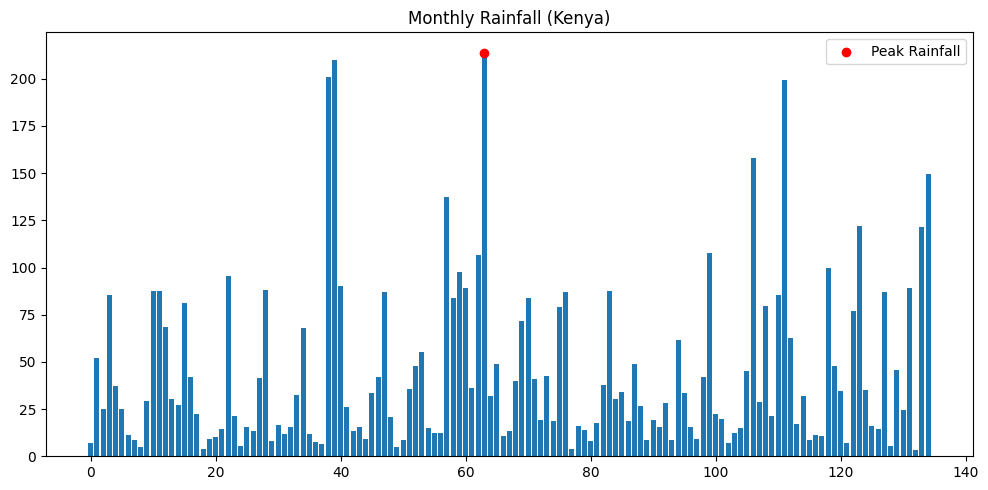

In [9]:
monthly_rain = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()

peak_rain = monthly_rain.loc[monthly_rain["PRECTOTCORR"].idxmax()]

plt.figure(figsize=(10,5))
plt.bar(range(len(monthly_rain)), monthly_rain["PRECTOTCORR"])

plt.scatter(peak_rain.name, peak_rain["PRECTOTCORR"], color='red', label="Peak Rainfall")

plt.title("Monthly Rainfall (Kenya)")
plt.legend()
plt.tight_layout()
plt.show()

## Rainfall Trend Analysis

The monthly rainfall distribution in Kenya shows clear seasonal variability, with most months experiencing low to moderate precipitation and a few periods of intense rainfall.

Peak rainfall exceeds *200 mm* in certain months, as highlighted in the plot, indicating the occurrence of extreme rainfall events. These peaks are relatively infrequent but significantly higher than the typical monthly values.

The majority of months receive less than *100 mm* of rainfall, demonstrating that precipitation is unevenly distributed throughout the year.

Additionally, multiple high-rainfall periods can be observed across the timeline, suggesting a pattern consistent with Kenya’s bimodal rainfall system, characterized by distinct rainy seasons separated by drier intervals.

Overall, the data reflects a climate with irregular but intense rainfall events, which are important for understanding seasonal weather patterns and potential flood risks.


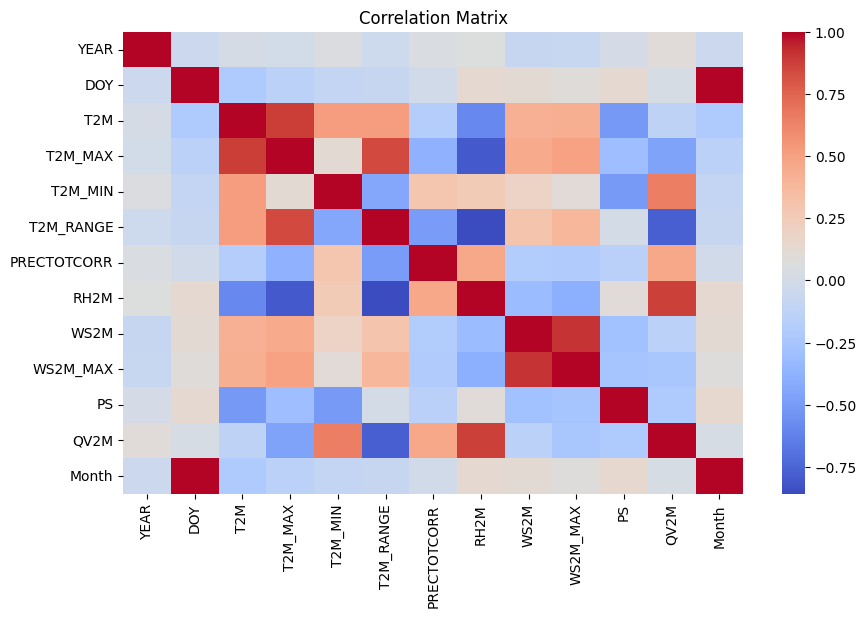

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Correlation Analysis

The correlation matrix reveals several strong relationships between key climate variables in Kenya.

The strongest correlations include:

- **WS2M and WS2M_MAX**  
  This strong positive correlation indicates that higher average wind speeds are associated with stronger maximum wind speeds.

- **T2M and T2M_MAX**  
  Average temperature is closely related to maximum temperature, reflecting consistent daily temperature patterns.

- **RH2M and QV2M**  
  Relative humidity and specific humidity are strongly correlated, indicating consistency in atmospheric moisture measurements.

Additionally, temperature-related variables show negative correlations with humidity and temperature range, suggesting that hotter conditions are often associated with drier and more stable atmospheric conditions.

Overall, the correlations align with expected physical relationships between climate variables, supporting the reliability of the dataset.

In [11]:
corr = df.corr(numeric_only=True)
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]

corr_pairs.head(10)

DOY        Month        0.996557
Month      DOY          0.996557
WS2M_MAX   WS2M         0.911457
WS2M       WS2M_MAX     0.911457
T2M_MAX    T2M          0.880907
T2M        T2M_MAX      0.880907
QV2M       RH2M         0.869546
RH2M       QV2M         0.869546
T2M_RANGE  T2M_MAX      0.841866
T2M_MAX    T2M_RANGE    0.841866
dtype: float64

# Top Correlations

The strongest correlations observed in the dataset are:

- DOY and Month (0.997)  
- WS2M_MAX and WS2M (0.911)  
- T2M_MAX and T2M (0.881)  
- QV2M and RH2M (0.870)  
- T2M_RANGE and T2M_MAX (0.842)  

The extremely high correlation between DOY (Day of Year) and Month is expected, as both variables represent time-related components and follow the same annual cycle.

Wind speed (WS2M) and maximum wind speed (WS2M_MAX) show a strong positive relationship, indicating that periods with higher average wind speeds are associated with stronger wind gusts.

Temperature variables also show strong correlations, particularly between average temperature (T2M) and maximum temperature (T2M_MAX), which reflects consistent temperature patterns throughout the day.

Additionally, specific humidity (QV2M) and relative humidity (RH2M) are highly correlated, highlighting the close relationship between atmospheric moisture content and humidity levels.

These relationships confirm expected physical connections between climate variables and validate the consistency of the dataset.

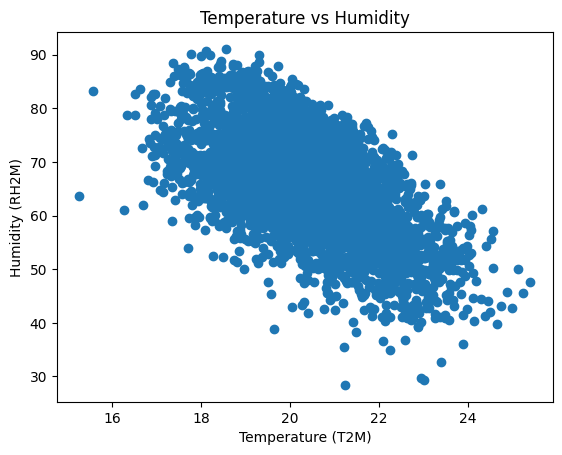

In [12]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.title("Temperature vs Humidity")
plt.show()

## Temperature vs Humidity Relationship

The scatter plot shows a clear negative relationship between temperature and relative humidity in Kenya.

As temperature increases, humidity tends to decrease, indicating that warmer conditions are generally associated with drier air.

This inverse relationship reflects typical atmospheric behavior, where higher temperatures increase evaporation rates, reducing relative humidity.

Overall, the pattern suggests a moderate negative correlation between these two climate variables.

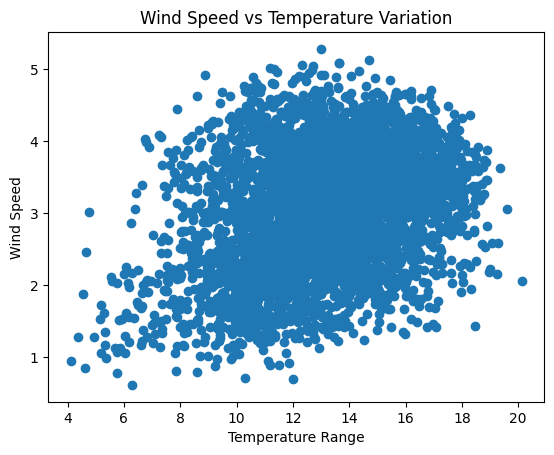

In [13]:
plt.figure()
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.title("Wind Speed vs Temperature Variation")
plt.show()

## Wind Speed vs Temperature Variation

The scatter plot shows little to no clear relationship between temperature range and wind speed in Kenya.

Temperature variations between approximately 4°C and 20°C are observed across a wide range of wind speeds, indicating no consistent dependency between the two variables.

This suggests that wind speed alone is not a strong driver of daily temperature variability in this dataset. Other atmospheric factors such as cloud cover, humidity, and regional weather systems are likely to have a greater influence on temperature fluctuations.

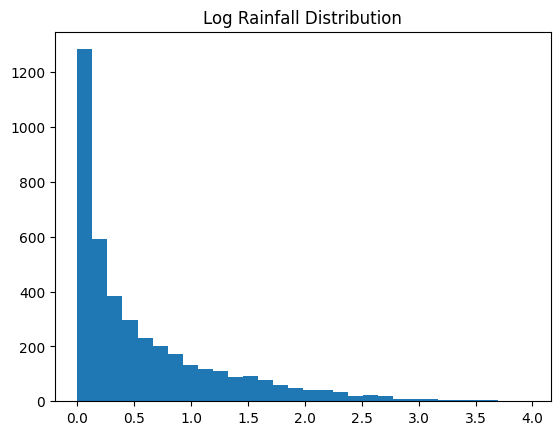

In [14]:
plt.figure()
plt.hist(np.log1p(df["PRECTOTCORR"]), bins=30)
plt.title("Log Rainfall Distribution")
plt.show()

## Rainfall Distribution Analysis

The log-transformed rainfall distribution reveals a strongly right-skewed pattern.

This indicates that most days in Kenya experience little to no rainfall, while a small number of days record significantly high precipitation events.

Applying a logarithmic transformation helps reduce the effect of extreme values and makes the overall distribution of rainfall more interpretable, allowing both low and high rainfall events to be visualized more clearly.

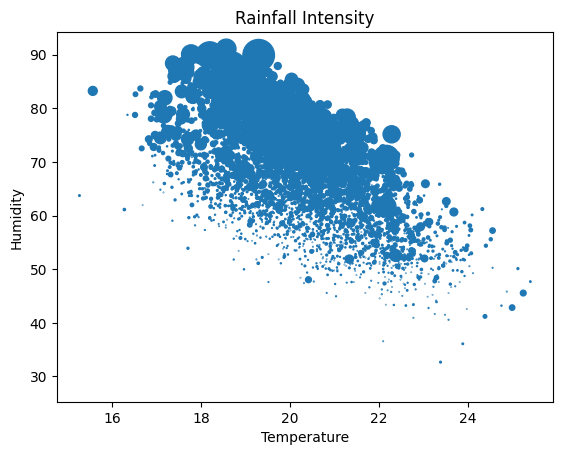

In [15]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Rainfall Intensity")
plt.show()

## Rainfall Intensity Relationship

The bubble chart shows the relationship between temperature, humidity, and rainfall intensity in Kenya.

Higher rainfall intensity (larger bubbles) tends to occur under conditions of higher relative humidity and moderate temperature levels.

In contrast, lower rainfall intensity is generally associated with drier conditions and more variable temperature levels.

Overall, the plot suggests that rainfall in Kenya is more strongly influenced by humidity levels than by temperature alone.

## References & Self-Learning

To support the analysis and better understand climate patterns in Kenya, external resources were consulted.

A key reference used:
[https://climateknowledgeportal.worldbank.org/sites/default/files/2021-05/15724-WB_Kenya%20Country%20Profile-WEB.pdf]

[https://www.powershiftafrica.org/publications/cop30scorecard]

## Key Learnings from the Reference

- Kenya experiences a **bimodal rainfall pattern**, with:
  - Long rains: March to May  
  - Short rains: October to December :contentReference[oaicite:0]{index=0}  

- Average annual temperature is approximately **24°C**, with relatively small seasonal variation :contentReference[oaicite:1]{index=1}  

- Rainfall is **highly seasonal and unevenly distributed**, which aligns with the variability observed in the dataset :contentReference[oaicite:2]{index=2}

In [16]:
df.to_csv("../data/kenya_clean.csv", index=False)


# Exporting Cleaned Data

The cleaned dataset was exported to a new CSV file for future use and reproducibility:
```python
df.to_csv("../data/kenya_clean.csv", index=False)